# Exploratory Data Analysis — Raw Transmission-Grid Data
### GNN Generalization for AC Power-Flow Prediction

**What this notebook is.** A complete exploration of the *raw* inputs to the
pipeline — the four transmission-grid models (IEEE24, IEEE39, IEEE118, UK) and
their real per-bus hourly demand profiles — performed **before** we generate any
graphs. It is the data-understanding step that should precede feature
engineering and modeling.

**Why we do it.** Before turning physics into ML samples we need to know:
- how different the four grids are in *size and structure* (this is the whole
  premise of a generalization study);
- what the *demand* data actually looks like (range, seasonality, anomalies);
- whether the grids live on wildly different *scales* (which decides whether we
  must normalize, and predicts which models will be scale-fragile);
- whether there are *data-quality* problems (NaNs, negatives, disconnected
  grids) that would silently corrupt the dataset.

**How it's organized.** Each step below has a short markdown preamble
(*what / why*), the code, and a **Findings & implication** note interpreting the
output for the next stage of the pipeline.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

# Make the pipeline importable and point at PowerGraph's raw demand files.
REPO = "/home/ubuntu/repos/eval_gnn_generalization_pg"
sys.path.insert(0, REPO)
os.environ.setdefault(
    "POWERGRAPH_NODE_DIR",
    "/home/ubuntu/powergraph/PowerGraph-Node-main/13_Power_system",
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import pandapower as pp

from transmission_grids import get_transmission_grid_codes, load_case, load_hourly_demand

# Shared plotting style (white background, clean dashboard look).
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "axes.grid": True,
    "grid.color": "#e6e6e6", "grid.linewidth": 0.8,
    "axes.edgecolor": "#cccccc", "axes.titleweight": "bold",
    "font.size": 11,
})
GRIDS = get_transmission_grid_codes()
PALETTE = {"IEEE24": "#2b6cb0", "IEEE39": "#38a169", "IEEE118": "#d69e2e", "UK": "#c53030"}
print("Grids:", GRIDS)

Grids: ['IEEE24', 'IEEE39', 'IEEE118', 'UK']


## Step 1 — Load the raw data and confirm it solves

**What.** Load each PowerGraph grid case into a re-solvable pandapower network,
run a base-case AC power flow, and load the raw hourly demand matrix.

**Why.** This is the provenance/sanity gate: we confirm we can read exactly the
grids PowerGraph used (via `from_mpc`), that each grid *converges* at its base
case, and that the demand file lines up with the bus count — before we build a
single training sample on top of it.

In [2]:
rows = []
nets, demands = {}, {}
for code in GRIDS:
    net = load_case(code)
    pp.runpp(net)                     # base-case AC power flow
    d = load_hourly_demand(code)      # (N_bus, T) active demand in MW
    nets[code], demands[code] = net, d
    rows.append({
        "grid": code, "buses": len(net.bus), "loads": len(net.load),
        "gens": len(net.gen), "ext_grid(slack)": len(net.ext_grid),
        "lines": len(net.line), "trafos": len(net.trafo),
        "converged": bool(net.converged),
        "demand_shape": str(d.shape),
    })
overview = pd.DataFrame(rows).set_index("grid")
overview

There are 11 branches which are considered as trafos - due to ratio unequal 0 or 1 - but connect same voltage levels.


There are 2 branches which are considered as trafos - due to ratio unequal 0 or 1 - but connect same voltage levels.


some BR_B of transformers in ppc['branch'] are positive, but transformers are inductive, therefore their B should be negative


,buses,loads,gens,ext_grid(slack),lines,trafos,converged,demand_shape
grid,,,,,,,,
IEEE24,24,17,10,1,33,5,True,"(24, 35040)"
IEEE39,39,21,9,1,35,11,True,"(39, 35040)"
IEEE118,118,91,53,1,175,9,True,"(118, 35040)"
UK,29,29,23,1,86,4,True,"(29, 35040)"


**Findings & implication.** All four grids load and converge at the base case,
and every demand matrix has one row per bus and 35 040 columns (a full year at
15-minute resolution). The grids span a wide size range — from **IEEE24 (24
buses)** to **IEEE118 (118 buses)** — and the **UK** grid is unusual: nearly
every bus is a generator bus and it is *line-dense* (86 lines over 29 buses).
*Implication:* the pipeline's Step-1/Step-2 loaders are trustworthy, and we
already see the first hint that UK is structurally an outlier — worth watching
in the structural analysis below.

## Step 2 — Bus-type composition (slack / PV / PQ)

**What.** Count each grid's bus types: the single slack (`ext_grid`), the
voltage-controlled generator (PV) buses, and the remaining load/PQ buses.

**Why.** Bus type *is* the power-flow problem: it determines which quantities
are known inputs and which must be predicted (slack knows V/θ; PV knows P/V; PQ
knows P/Q). The class balance here directly drives the masking scheme and tells
us how much of each grid the model actually has to *predict* versus copy.

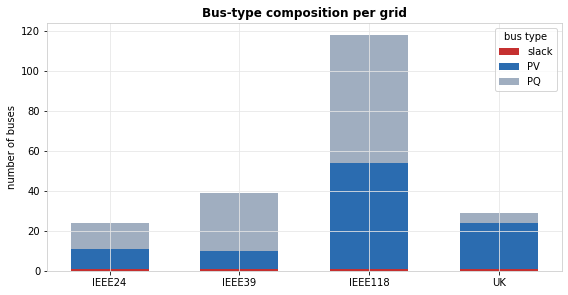

,slack,PV,PQ,total
grid,,,,
IEEE24,1,10,13,24
IEEE39,1,9,29,39
IEEE118,1,53,64,118
UK,1,23,5,29


In [3]:
comp = []
for code in GRIDS:
    net = nets[code]
    n = len(net.bus)
    n_slack = len(net.ext_grid)
    pv = set(net.gen.bus.tolist()) - set(net.ext_grid.bus.tolist())
    n_pv = len(pv)
    n_pq = n - n_slack - n_pv
    comp.append({"grid": code, "slack": n_slack, "PV": n_pv, "PQ": n_pq, "total": n})
comp = pd.DataFrame(comp).set_index("grid")

fig, ax = plt.subplots(figsize=(8, 4.2))
bottom = np.zeros(len(GRIDS))
for typ, col in [("slack", "#c53030"), ("PV", "#2b6cb0"), ("PQ", "#a0aec0")]:
    vals = comp.loc[GRIDS, typ].values
    ax.bar(GRIDS, vals, bottom=bottom, label=typ, color=col, width=0.6)
    bottom += vals
ax.set_ylabel("number of buses"); ax.set_title("Bus-type composition per grid")
ax.legend(title="bus type"); plt.tight_layout(); plt.show()
comp

**Findings & implication.** IEEE24/39/118 are **load-dominated** (mostly PQ
buses — the quantities the model must predict), whereas **UK is
generator-dominated** (23 of 29 buses are PV, so V is largely a known input
there). *Implication:* the prediction task is qualitatively different on UK — a
model transferring to UK faces a very different known/unknown mix, which helps
explain why UK is the hard out-of-distribution grid later. It also confirms the
per-bus-type masking is essential, not cosmetic.

## Step 3 — Structural analysis: degree distribution & connectivity

**What.** Build the undirected graph of each grid (buses = nodes, in-service
branches = edges) and examine node **degree** (how many lines meet at a bus) and
whether the grid is **connected**.

**Why.** The generalization claim rests on the grids being *structurally
different*. Degree distribution is the simplest structural fingerprint (it is
literally one of the two descriptors our MMD uses). Connectivity matters because
an islanded grid has no single power-flow solution — this is the property the
contingency sampler must preserve.

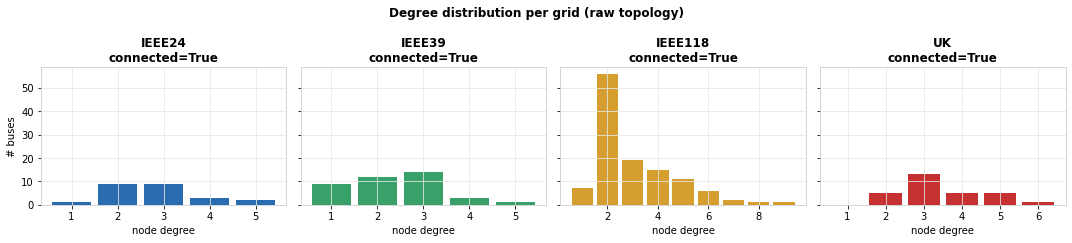

,mean_deg,max_deg,connected,avg_shortest_path
grid,,,,
IEEE24,2.833333,5,True,3.21
IEEE39,2.358974,5,True,4.75
IEEE118,3.033898,9,True,6.31
UK,3.448276,6,True,3.95


In [4]:
def grid_to_nx(net):
    G = nx.Graph()
    G.add_nodes_from(net.bus.index.tolist())
    for _, r in net.line[net.line.in_service].iterrows():
        G.add_edge(int(r.from_bus), int(r.to_bus))
    for _, r in net.trafo[net.trafo.in_service].iterrows():
        G.add_edge(int(r.hv_bus), int(r.lv_bus))
    # some PowerGraph grids also carry series-impedance branches
    if len(net.impedance):
        for _, r in net.impedance[net.impedance.in_service].iterrows():
            G.add_edge(int(r.from_bus), int(r.to_bus))
    return G

def avg_path_len(G):
    # average shortest-path length over the largest connected component
    if nx.is_connected(G):
        H = G
    else:
        H = G.subgraph(max(nx.connected_components(G), key=len))
    return round(nx.average_shortest_path_length(H), 2)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), sharey=True)
deg_rows = []
for ax, code in zip(axes, GRIDS):
    G = grid_to_nx(nets[code])
    degs = [d for _, d in G.degree()]
    ax.hist(degs, bins=range(1, max(degs) + 2), color=PALETTE[code],
            align="left", rwidth=0.85)
    ax.set_title(f"{code}\nconnected={nx.is_connected(G)}")
    ax.set_xlabel("node degree")
    deg_rows.append({"grid": code, "mean_deg": np.mean(degs), "max_deg": max(degs),
                     "connected": nx.is_connected(G),
                     "avg_shortest_path": avg_path_len(G)})
axes[0].set_ylabel("# buses")
fig.suptitle("Degree distribution per grid (raw topology)", fontweight="bold")
plt.tight_layout(); plt.show()
pd.DataFrame(deg_rows).set_index("grid")

**Findings & implication.** Every grid is a single connected component once
series-impedance branches are included (good — the base topology is solvable;
note two IEEE118 buses connect *only* via impedance branches, which is why we
add them explicitly). The degree profiles differ markedly: **UK has the highest
mean distinct-neighbour degree (~3.5)** and, because it carries many *parallel*
circuits, by far the highest branch density — while **IEEE118 has the longest
average path length** simply because it is the largest grid. *Implication:* the
grids are genuinely different in local connectivity, foreshadowing the MMD
result that UK is the structural outlier. And because the sparse IEEE grids sit
close to the connectivity edge, the contingency sampler's **islanding
rejection** does real work — removing lines *can* disconnect them.

## Step 4 — Line electrical parameters (r, x)

**What.** Look at the distribution of per-branch resistance `r` and reactance
`x` (the edge features the GNN receives), across grids.

**Why.** These are the physical quantities that make one grid behave
differently from another and that populate `edge_attr`. If their scales differ
across grids, an edge-conditioned model (e.g. NNConv, which builds a weight
matrix per edge from these) can over-fit one grid's parameter range and fail to
transfer.

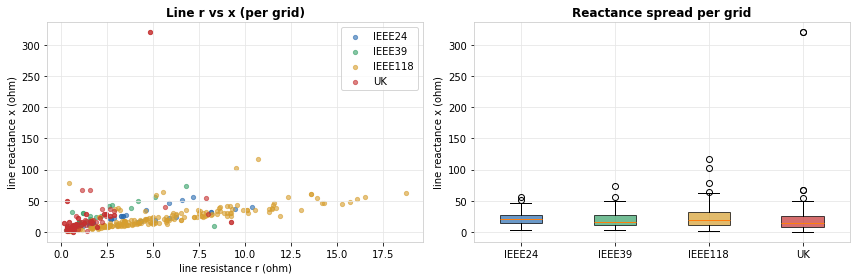

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for code in GRIDS:
    net = nets[code]
    r = net.line["r_ohm_per_km"].values * net.line["length_km"].values
    x = net.line["x_ohm_per_km"].values * net.line["length_km"].values
    axes[0].scatter(r, x, s=18, alpha=0.6, color=PALETTE[code], label=code)
axes[0].set_xlabel("line resistance r (ohm)"); axes[0].set_ylabel("line reactance x (ohm)")
axes[0].set_title("Line r vs x (per grid)"); axes[0].legend()

data = []
labels = []
for code in GRIDS:
    net = nets[code]
    xohm = net.line["x_ohm_per_km"].values * net.line["length_km"].values
    data.append(xohm); labels.append(code)
bp = axes[1].boxplot(data, labels=labels, patch_artist=True)
for patch, code in zip(bp["boxes"], GRIDS):
    patch.set_facecolor(PALETTE[code]); patch.set_alpha(0.7)
axes[1].set_ylabel("line reactance x (ohm)"); axes[1].set_title("Reactance spread per grid")
plt.tight_layout(); plt.show()

**Findings & implication.** The r–x clouds occupy different regions per grid and
the reactance spread varies substantially, confirming the edge features are not
on a common scale across grids. *Implication:* edge normalization matters, and
this is a mechanistic reason to expect the most edge-expressive model
(**NNConv**, a 64×64 matrix per edge) to be the least robust across grids — it
has the capacity to memorize a single grid's parameter range. This EDA
observation is later borne out: NNConv is the only model that fails in both
transfer regimes.

## Step 5 — Demand profiles: scale and distribution

**What.** Summarize the raw per-bus active demand (MW) per grid, and plot the
distribution of demand values.

**Why.** Demand is the *only* time-varying input in PowerGraph's regime and
becomes the load setpoints we solve for. Its scale differs enormously across
grids, which determines whether target power values (`P`, `Q`) also differ in
scale — the single biggest driver of transfer difficulty and the reason we
report **range-normalized** NRMSE.

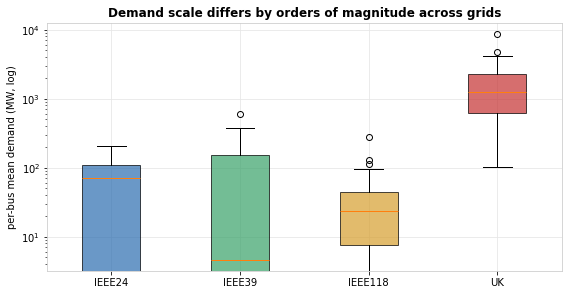

,n_bus,T,min,median,mean,max,zeros_%,nan,neg
grid,,,,,,,,,
IEEE24,24,35040,0.00,68.11,72.96,333.0,29.2,0,0
IEEE39,39,35040,0.00,4.31,87.64,1102.9,46.2,0,0
IEEE118,118,35040,0.00,23.66,31.64,446.9,22.9,0,0
UK,29,35040,62.19,1207.30,1705.15,13599.7,0.0,0,0


In [6]:
stat_rows = []
for code in GRIDS:
    d = demands[code]
    stat_rows.append({
        "grid": code, "n_bus": d.shape[0], "T": d.shape[1],
        "min": round(float(d.min()), 2), "median": round(float(np.median(d)), 2),
        "mean": round(float(d.mean()), 2), "max": round(float(d.max()), 1),
        "zeros_%": round(100 * float((d == 0).mean()), 1),
        "nan": int(np.isnan(d).sum()), "neg": int((d < 0).sum()),
    })
demand_stats = pd.DataFrame(stat_rows).set_index("grid")

fig, ax = plt.subplots(figsize=(8, 4.2))
# per-bus mean demand distribution, log-y to compare across scales
data = [demands[c].mean(axis=1) for c in GRIDS]
bp = ax.boxplot(data, labels=GRIDS, patch_artist=True)
for patch, code in zip(bp["boxes"], GRIDS):
    patch.set_facecolor(PALETTE[code]); patch.set_alpha(0.7)
ax.set_yscale("log"); ax.set_ylabel("per-bus mean demand (MW, log)")
ax.set_title("Demand scale differs by orders of magnitude across grids")
plt.tight_layout(); plt.show()
demand_stats

**Findings & implication.** Demand scale differs by **orders of magnitude**:
UK's per-bus loads reach ~13.6 GW while IEEE24 tops out around 330 MW. No NaNs
or negative demands (clean data), though some buses carry zero active load
(non-load buses). *Implication:* raw `P`/`Q` targets are not comparable across
grids, so (a) our range-normalized NRMSE is the right metric, and (b) any model
that aggregates by an **unnormalized sum** (GIN) is at high risk of
scale-explosion when transferring between grids — again matching the later
finding that GIN is the most fragile in single-grid transfer.

## Step 6 — Temporal & seasonal structure of demand

**What.** Aggregate total system demand over time and view (a) the yearly
profile and (b) the average daily profile, for one representative grid.

**Why.** Our sampler draws demand *snapshots*; we need to know whether those
snapshots span a meaningful operating envelope (seasonal peaks, daily
peak/off-peak) or are near-constant. Good temporal spread means the topology
distribution is crossed with a realistic range of loading conditions.

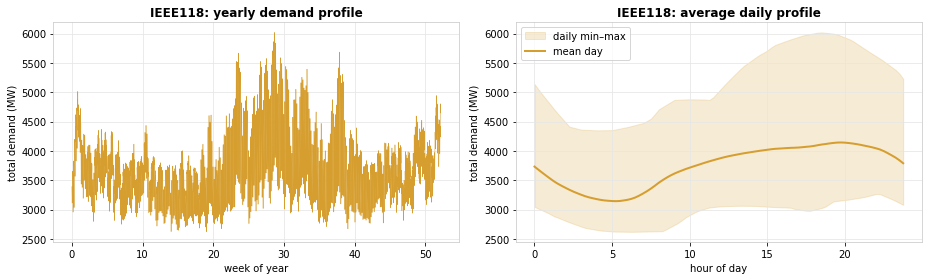

peak/trough ratio (yearly): 2.3


In [7]:
code0 = "IEEE118"
d = demands[code0]
total = d.sum(axis=0)                    # total system demand per 15-min step
steps_per_day = 96
n_days = total.shape[0] // steps_per_day
daily = total[: n_days * steps_per_day].reshape(n_days, steps_per_day)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(np.arange(total.shape[0]) / (steps_per_day * 7), total, lw=0.5, color=PALETTE[code0])
axes[0].set_xlabel("week of year"); axes[0].set_ylabel("total demand (MW)")
axes[0].set_title(f"{code0}: yearly demand profile")

mean_day = daily.mean(axis=0); lo = daily.min(axis=0); hi = daily.max(axis=0)
hrs = np.arange(steps_per_day) / 4.0
axes[1].fill_between(hrs, lo, hi, color=PALETTE[code0], alpha=0.2, label="daily min–max")
axes[1].plot(hrs, mean_day, color=PALETTE[code0], lw=2, label="mean day")
axes[1].set_xlabel("hour of day"); axes[1].set_ylabel("total demand (MW)")
axes[1].set_title(f"{code0}: average daily profile"); axes[1].legend()
plt.tight_layout(); plt.show()

print("peak/trough ratio (yearly):", round(float(total.max() / total.min()), 2))

**Findings & implication.** Demand shows clear **seasonal** variation across the
year and a pronounced **daily peak/off-peak** cycle, with a healthy
peak-to-trough ratio. *Implication:* sampling demand snapshots genuinely varies
the loading condition, so crossing them with topology contingencies produces a
rich (demand × topology) distribution rather than near-duplicate samples — which
is exactly what we need for the solved states to be diverse. It also suggests a
sampling refinement: **stratify snapshots across seasons/day-parts** so peak
stress cases are represented, not just average loading.

## Step 7 — Cross-grid structural summary (the generalization premise)

**What.** Collect the per-grid structural fingerprints (size, density, mean
degree, average path length, demand scale) into one comparison table.

**Why.** This is the one-look justification that a *leave-one-grid-out* study is
meaningful: if the grids were near-identical, "generalization to an unseen grid"
would be trivial. This table is the raw-data precursor to the MMD analysis.

In [8]:
summary = []
for code in GRIDS:
    net = nets[code]; G = grid_to_nx(net)
    n = len(net.bus)
    e = (len(net.line[net.line.in_service]) + len(net.trafo[net.trafo.in_service])
         + (len(net.impedance[net.impedance.in_service]) if len(net.impedance) else 0))
    summary.append({
        "grid": code, "buses": n, "branches": e,
        "density(2E/N)": round(2 * e / n, 2),
        "mean_degree": round(np.mean([d for _, d in G.degree()]), 2),
        "avg_path_len": avg_path_len(G),
        "connected": nx.is_connected(G),
        "demand_max_MW": round(float(demands[code].max()), 0),
    })
pd.DataFrame(summary).set_index("grid")

,buses,branches,density(2E/N),mean_degree,avg_path_len,connected,demand_max_MW
grid,,,,,,,
IEEE24,24,38,3.17,2.83,3.21,True,333.0
IEEE39,39,46,2.36,2.36,4.75,True,1103.0
IEEE118,118,186,3.15,3.03,6.31,True,447.0
UK,29,99,6.83,3.45,3.95,True,13600.0


**Findings & implication.** The four grids differ on **every** axis — size (24→
118 buses), branch density, mean degree, path length, and demand scale (hundreds
of MW → ~13.6 GW). UK is the outlier on density/degree/demand, while IEEE118 is
the outlier on sheer size and path length.
*Implication:* the generalization question is well-posed — transfer results will
be over *real* structural distance. This directly motivates (1) computing a
principled topological distance (**MMD** on degree + Laplacian-spectrum
distributions), and (2) expecting UK to be the hardest held-out grid.

## Step 8 — Overall conclusions & implications for next steps

**What the EDA established (findings):**
1. **Data is clean and trustworthy** — all grids load, converge, and align with
   their demand matrices; no NaNs or negative demands.
2. **The grids are genuinely heterogeneous** — size, density, degree, path
   length and demand scale all differ; **UK is a structural outlier** (dense,
   generator-dominated, GW-scale demand).
3. **Scales are not comparable across grids** — demand and line parameters span
   orders of magnitude, and bus-type balance differs.
4. **Demand has rich temporal structure** — seasonal + daily cycles give a real
   loading envelope to cross with topology contingencies.

**Implications for the pipeline (next steps):**
- **Normalize** — use range-normalized NRMSE and normalized inputs, because raw
  `P`/`Q` are not comparable across grids.
- **Preserve connectivity** — islanding rejection in the contingency sampler is
  necessary (base grids are connected but sparse IEEE grids fragment easily).
- **Expect scale-driven fragility** — unnormalized-sum (GIN) and per-edge-matrix
  (NNConv) models are the a-priori transfer risks; the EDA predicts this before
  a single model is trained.
- **Quantify distance** — the heterogeneity justifies the MMD descriptors and a
  distance-aware g-score; UK should be the hardest OOD target.
- **Stratify sampling** — draw demand snapshots across seasons/day-parts so peak
  stress conditions are represented.

This EDA is the *why* behind the design decisions in the rest of the pipeline —
it turns "we normalized and used MMD" into evidence-backed choices.